# Quantized Fourier Compression of Timeseries Data with Application to Electrophysiology

## Overview

See [Compression strategies for large-scale electrophysiology data, Buccino et al.](https://www.biorxiv.org/content/10.1101/2023.05.22.541700v2.full.pdf).

With the increasing sizes of data for extracellular electrophysiology, it is crucial to develop efficient methods for compressing multi-channel time series data. While lossless methods are desirable for perfectly preserving the original signal, the compression ratios for these methods usually range only from 2-4x. What is needed are ratios on the order of 10-30x, leading us to consider lossy methods.

Here, we propose a simple lossy compression method, inspired by the Discrete Cosine Transform (DCT) and the quantization steps of JPEG compression for images. The method comprises the following steps:
* Compute the Discrete Fourier Transform (DFT) of the time series data in the time domain.
* Quantize the Fourier coefficients to achieve a target entropy (the entropy determines the theoretically achievable compression ratio). This is done by multiplying by a normalization factor and then rounding to the nearest integer.
* Compress the reduced-entropy quantized Fourier coefficients using GZIP (other methods could also be used).

To decompress:
* Unzip the quantized Fourier coefficients.
* Divide by the normalization factor.
* Compute the Inverse Discrete Fourier Transform (IDFT) to obtain the reconstructed time series data.

This method is particularly well-suited for data that has been bandpass-filtered, as the suppressed Fourier coefficients yield an especially low entropy of the quantized signal.

In this notebook, we define three functions:

* `qfc_compress`: Compresses a time series data array.
* `qfc_decompress`: Decompresses a time series data array.
* `qfc_estimate_normalization_factor`: Estimates the normalization factor for the QFC algorithm for a given target compression ratio.

Then, we try out the method using some real electrophysiology data from [a public dandiset](https://dandiarchive.org/dandiset/000784).

## Define the functions

First let's define `qfc_compress`, `qfc_decompress`, and `qfc_estimate_normalization_factor`.

In [1]:
import os
import numpy as np
import zlib
import time


def qfc_compress(
    x: np.ndarray,
    normalization_factor: float
):
    """
    Compresses an array using the QFC algorithm

    Parameters
    ----------
    x : np.ndarray
        The input array to be compressed
    normalization_factor : float
        The normalization factor to use during compression, obtained from qfc_estimate_normalization_factor

    Returns
    -------
    np.ndarray
        The compressed array
    """
    x_fft = np.fft.rfft(x, axis=0)
    x_fft_re = np.real(x_fft)
    x_fft_im = np.imag(x_fft)
    x_fft_im = x_fft_im[1:-1]  # the first and last values are always zero
    x_fft_concat = np.concatenate([x_fft_re, x_fft_im], axis=0)
    x_fft_concat_quantized = np.round(x_fft_concat * normalization_factor).astype(np.int16)
    compressed_bytes = zlib.compress(x_fft_concat_quantized.tobytes())
    return compressed_bytes

def qfc_decompress(
    compressed_bytes: bytes,
    normalization_factor: float,
    original_shape: tuple
):
    """
    Decompresses an array using the QFC algorithm

    Parameters
    ----------
    compressed_bytes : bytes
        The compressed array
    normalization_factor : float
        The normalization factor used during compression
    original_shape : tuple
        The original shape of the array
        
    Returns
    -------
    np.ndarray
        The decompressed array
    """
    num_samples = original_shape[0]
    num_channels = original_shape[1]
    decompressed_array = np.frombuffer(zlib.decompress(compressed_bytes), dtype=np.int16)
    decompressed_array = decompressed_array.reshape(num_samples, num_channels)
    x_fft_re = decompressed_array[:(num_samples // 2 + 1), :] / normalization_factor
    x_fft_im = decompressed_array[(num_samples // 2 + 1):, :] / normalization_factor
    x_fft_im = np.concatenate([np.zeros((1, num_channels)), x_fft_im, np.zeros((1, num_channels))], axis=0)
    x_fft = x_fft_re + 1j * x_fft_im
    x = np.fft.irfft(x_fft, axis=0)
    return x


def qfc_estimate_normalization_factor(
    x: np.ndarray,
    target_compression_ratio: float
):
    """
    Estimates the normalization factor for the QFC algorithm for a given target compression ratio

    Parameters
    ----------
    x : np.ndarray
        The input array to be compressed
    target_compression_ratio : float
        The target compression ratio

    Returns
    -------
    float
        The normalization factor
    """
    x_fft = np.fft.rfft(x, axis=0)
    x_fft_re = np.real(x_fft)
    x_fft_im = np.imag(x_fft)
    x_fft_im = x_fft_im[1:-1]  # the first and last values are always zero
    values = np.concatenate([x_fft_re, x_fft_im], axis=0).ravel()

    # sample at most 5000 values to estimate the normalization factor
    # do it deterministically to avoid randomness in the results
    if values.size > 5000:
        indices = np.linspace(0, values.size - 1, 5000).astype(np.int32)
        values = values[indices]

    max_abs_value = np.max(np.abs(values))

    def _estimate_entropy(
        values: np.ndarray
    ):
        """
        Computes the entropy of an array

        Parameters
        ----------
        values : np.ndarray
            The values to compute the entropy of

        Returns
        -------
        float
            The entropy of the array
        """
        unique_values, counts = np.unique(values, return_counts=True)
        probabilities = counts / values.size
        entropy = -np.sum(probabilities * np.log2(probabilities))
        return entropy

    candidates = np.arange(1, 1000, 1) * 1 / max_abs_value
    entropies = np.array([_estimate_entropy(np.round(values * candidate).astype(np.int16)) for candidate in candidates])
    num_bits_per_value_in_original_array = np.dtype(x.dtype).itemsize * 8
    target_entropy = float(num_bits_per_value_in_original_array) / target_compression_ratio
    normalization_factor = candidates[np.argmin(np.abs(entropies - target_entropy))]
    return normalization_factor

## Load example data

Before proceeding, you need to download and prepare the example data by running:

```
python prepare_example_data.py
``````

In [2]:
if not os.path.exists('example_traces_filtered.npy'):
    print('Data not found. Please run the data generation script first.')
    raise Exception('Data not found. Please run the data generation script first.')

traces = np.load('example_traces_filtered.npy')
grid = np.arange(0, traces.shape[0], 1) / 30000
x = traces
print('Data has been loaded.')

Data has been loaded.


## Try out compression / decompression

In [3]:
target_compression_ratio = 20

timer = time.time()
normalization_factor = qfc_estimate_normalization_factor(x, target_compression_ratio)
elapsed_normalization = time.time() - timer

timer = time.time()
y = qfc_compress(x, normalization_factor=normalization_factor)
elapsed_compression = time.time() - timer

timer = time.time()
x_recon = qfc_decompress(y, normalization_factor, x.shape)
elapsed_decompression = time.time() - timer

resid = x - x_recon
compression_ratio = len(x.tobytes()) / len(y)
print(f"Target compression ratio: {target_compression_ratio}")
print(f"Actual compression ratio: {compression_ratio}")
print(f'Original size (MB): {len(x.tobytes()) / 1024 / 1024}')
print(f'Compressed size (MB): {len(y) / 1024 / 1024}')
print(f"Normalization time: {elapsed_normalization} seconds")
print(f"Compression time: {elapsed_compression} seconds")
print(f"Decompression time: {elapsed_decompression} seconds")
print(f"Std. dev. of residual: {np.std(resid)}")

Target compression ratio: 20
Actual compression ratio: 20.38514114321358
Original size (MB): 21.97265625
Compressed size (MB): 1.077876091003418
Normalization time: 0.2961866855621338 seconds
Compression time: 0.5296683311462402 seconds
Decompression time: 0.2736399173736572 seconds
Std. dev. of residual: 1.6221313000244646


## Plot the results for a selected channel and show the histogram and power spectrum of the residual

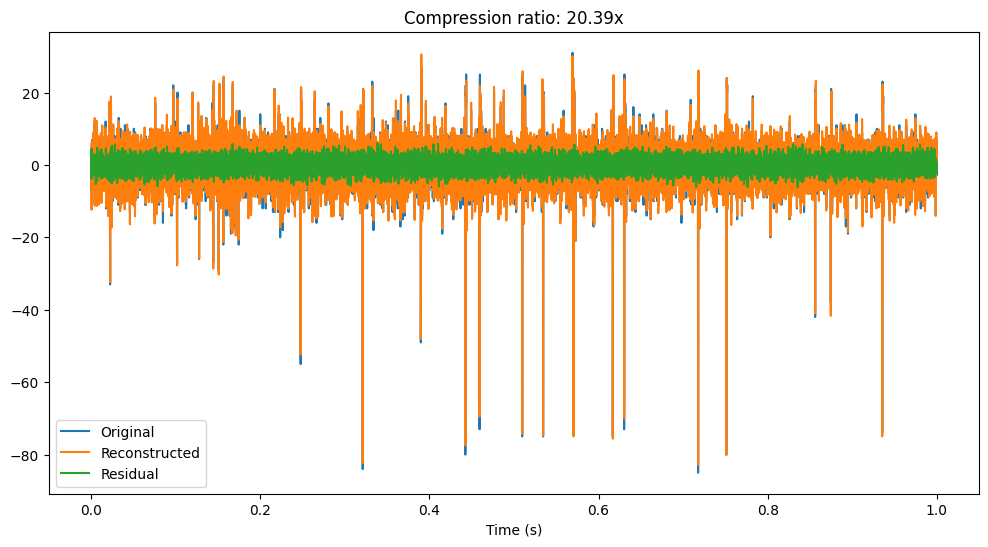

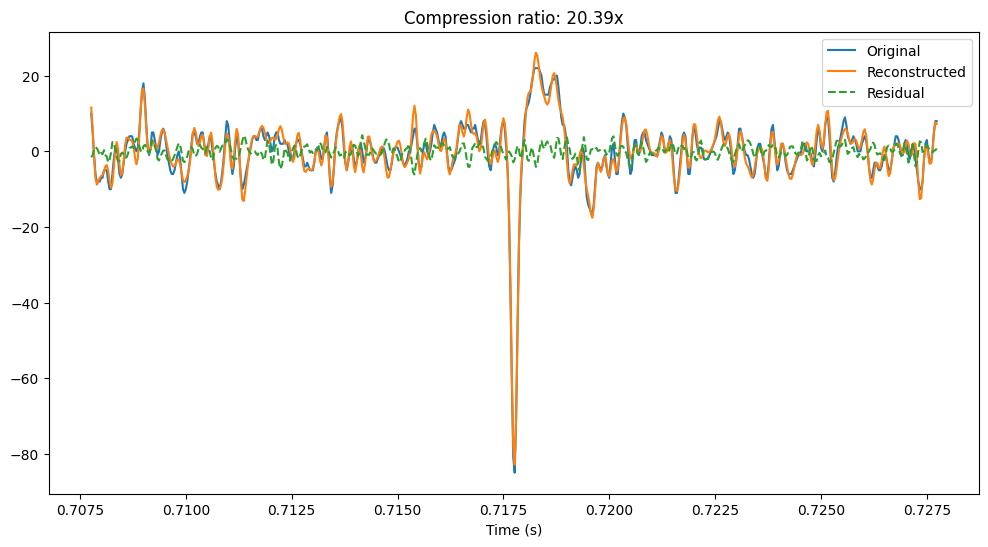

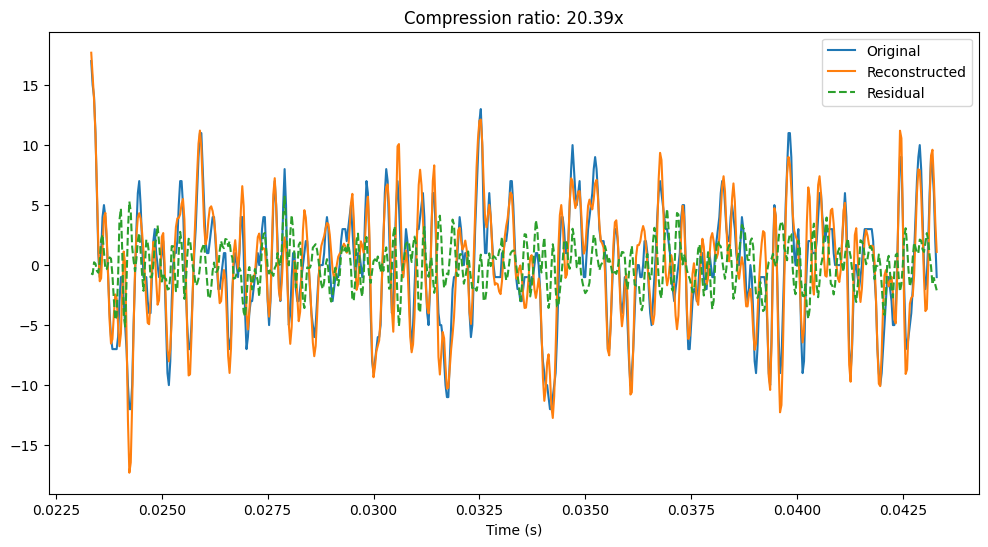

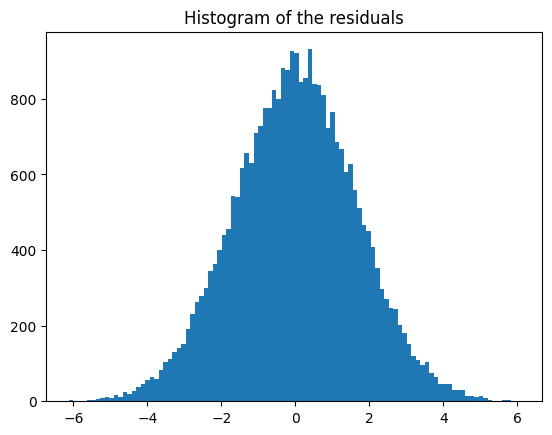

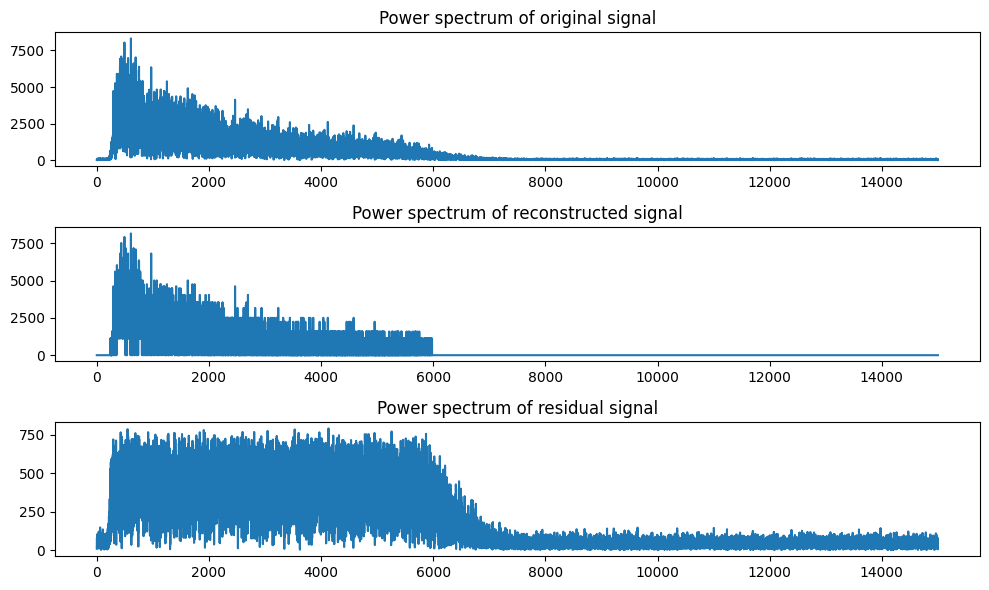

In [4]:
channel = 190

import matplotlib.pyplot as plt
plt.figure(figsize=(1200/100, 600/100), dpi=100)
plt.plot(grid, x[:, channel], label="Original")
plt.plot(grid, x_recon[:, channel], label="Reconstructed")
plt.plot(grid, resid[:, channel], label="Residual")
plt.title(f'Compression ratio: {compression_ratio:.2f}x')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

# zoom in on a single spike
ind = np.argmin(x[:, channel])
rng = [ind - 300, ind + 300]
plt.figure(figsize=(1200/100, 600/100), dpi=100)
plt.plot(grid[rng[0]:rng[1]], x[rng[0]:rng[1], channel], label="Original")
plt.plot(grid[rng[0]:rng[1]], x_recon[rng[0]:rng[1], channel], label="Reconstructed")
plt.plot(grid[rng[0]:rng[1]], resid[rng[0]:rng[1], channel], '--', label="Residual")
plt.title(f'Compression ratio: {compression_ratio:.2f}x')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

# zoom in on a lower amplitude spike
ind = 1000
rng = [ind - 300, ind + 300]
plt.figure(figsize=(1200/100, 600/100), dpi=100)
plt.plot(grid[rng[0]:rng[1]], x[rng[0]:rng[1], channel], label="Original")
plt.plot(grid[rng[0]:rng[1]], x_recon[rng[0]:rng[1], channel], label="Reconstructed")
plt.plot(grid[rng[0]:rng[1]], resid[rng[0]:rng[1], channel], '--', label="Residual")
plt.title(f'Compression ratio: {compression_ratio:.2f}x')
plt.xlabel('Time (s)')
plt.legend()

# Show the histogram of the residuals

plt.figure()
plt.hist(resid[:, channel], bins=100)
plt.title("Histogram of the residuals")
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(1000/100, 600/100), dpi=100)

# Power spectrum of original signal
axs[0].plot(np.abs(np.fft.rfft(x[:, channel])))
axs[0].set_title('Power spectrum of original signal')

# Power spectrum of reconstructed signal
axs[1].plot(np.abs(np.fft.rfft(x_recon[:, channel])))
axs[1].set_title('Power spectrum of reconstructed signal')

# Power spectrum of residual signal
axs[2].plot(np.abs(np.fft.rfft(resid[:, channel])))
axs[2].set_title('Power spectrum of residual signal')

# Display the plot
plt.tight_layout()
plt.show()

## Try with unfiltered data

Now let's try the same thing with unfiltered data.

In [5]:
traces_unfiltered = np.load('example_traces.npy')
grid = np.arange(0, traces_unfiltered.shape[0], 1) / 30000
x = traces_unfiltered
print('Data has been loaded.')

Data has been loaded.


In [6]:
timer = time.time()
normalization_factor = qfc_estimate_normalization_factor(x, target_compression_ratio)
elapsed_normalization = time.time() - timer

timer = time.time()
y = qfc_compress(x, normalization_factor=normalization_factor)
elapsed_compression = time.time() - timer

timer = time.time()
x_recon = qfc_decompress(y, normalization_factor, x.shape)
elapsed_decompression = time.time() - timer

resid = x - x_recon
compression_ratio = len(x.tobytes()) / len(y)
print(f"Target compression ratio: {target_compression_ratio}")
print(f"Actual compression ratio: {compression_ratio}")
print(f'Original size (MB): {len(x.tobytes()) / 1024 / 1024}')
print(f'Compressed size (MB): {len(y) / 1024 / 1024}')
print(f"Normalization time: {elapsed_normalization} seconds")
print(f"Compression time: {elapsed_compression} seconds")
print(f"Decompression time: {elapsed_decompression} seconds")
print(f"Std. dev. of residual: {np.std(resid)}")

Target compression ratio: 20
Actual compression ratio: 14.723361834285495
Original size (MB): 21.97265625
Compressed size (MB): 1.4923667907714844
Normalization time: 0.2098686695098877 seconds
Compression time: 0.6320171356201172 seconds
Decompression time: 0.3002305030822754 seconds
Std. dev. of residual: 2.680398484468813


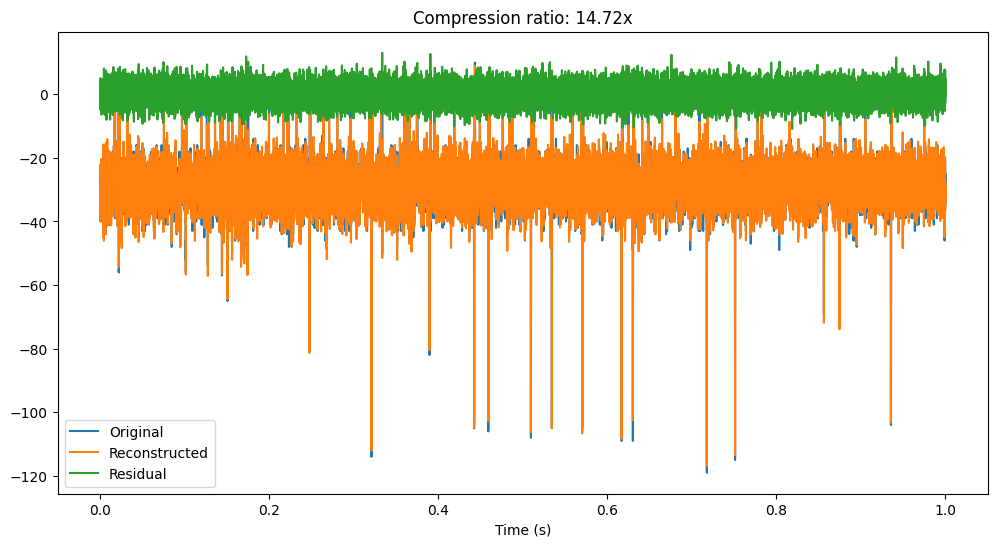

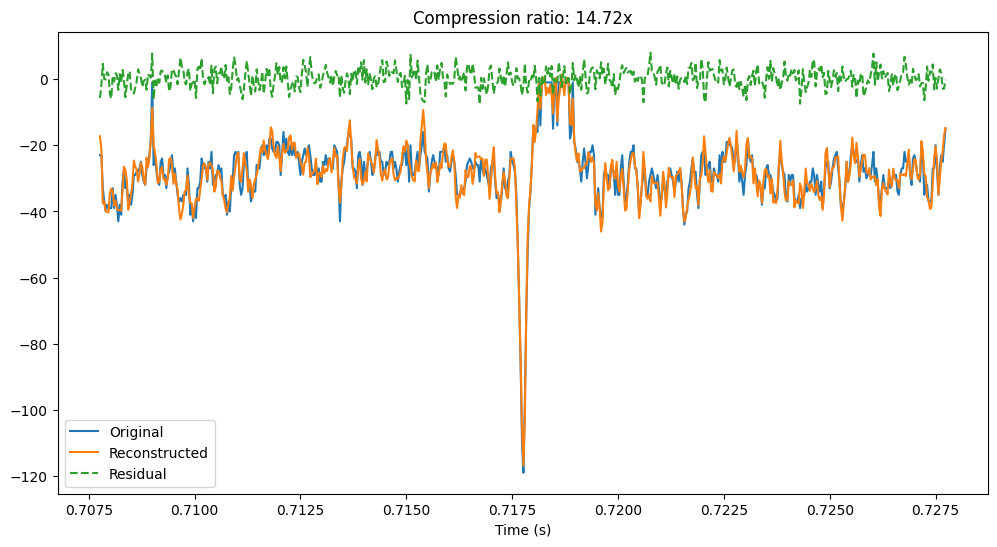

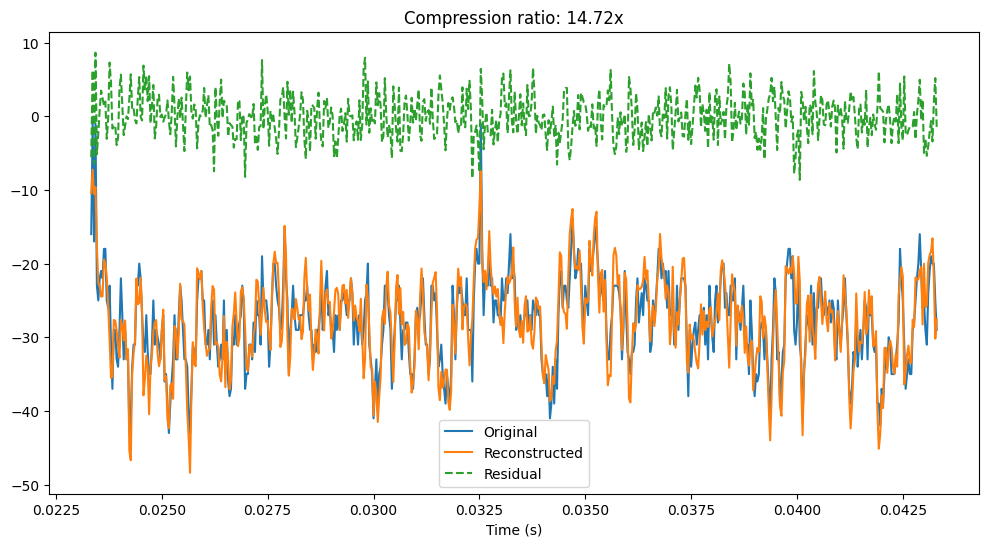

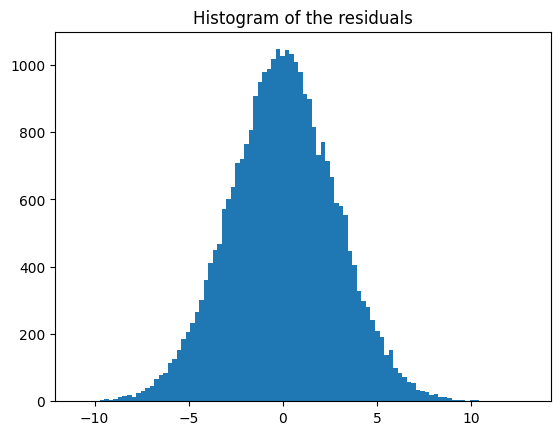

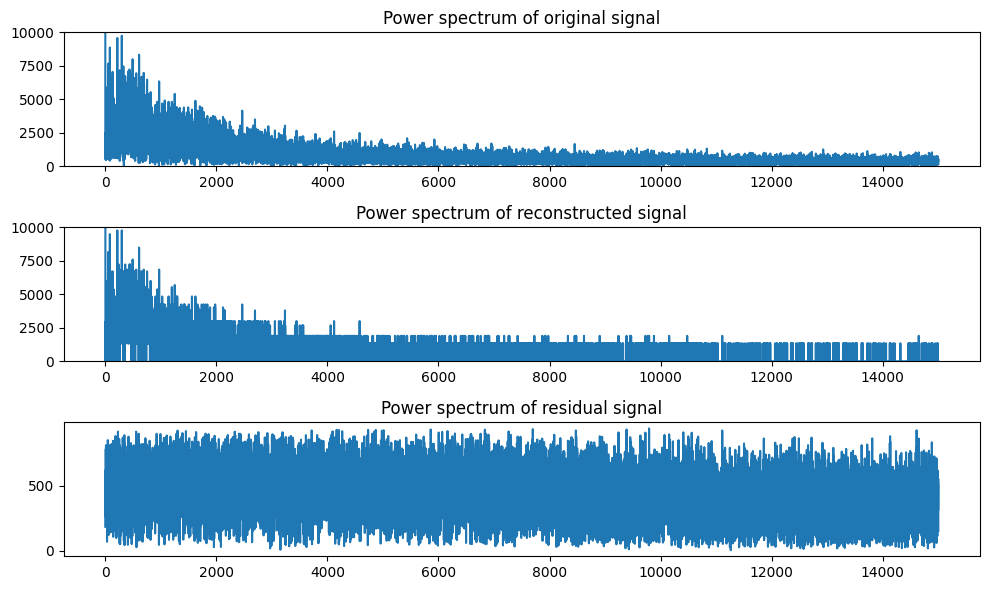

In [7]:
channel = 190

import matplotlib.pyplot as plt
plt.figure(figsize=(1200/100, 600/100), dpi=100)
plt.plot(grid, x[:, channel], label="Original")
plt.plot(grid, x_recon[:, channel], label="Reconstructed")
plt.plot(grid, resid[:, channel], label="Residual")
plt.title(f'Compression ratio: {compression_ratio:.2f}x')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

# zoom in on a single spike
ind = np.argmin(x[:, channel])
rng = [ind - 300, ind + 300]
plt.figure(figsize=(1200/100, 600/100), dpi=100)
plt.plot(grid[rng[0]:rng[1]], x[rng[0]:rng[1], channel], label="Original")
plt.plot(grid[rng[0]:rng[1]], x_recon[rng[0]:rng[1], channel], label="Reconstructed")
plt.plot(grid[rng[0]:rng[1]], resid[rng[0]:rng[1], channel], '--', label="Residual")
plt.title(f'Compression ratio: {compression_ratio:.2f}x')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

# zoom in on a lower amplitude spike
ind = 1000
rng = [ind - 300, ind + 300]
plt.figure(figsize=(1200/100, 600/100), dpi=100)
plt.plot(grid[rng[0]:rng[1]], x[rng[0]:rng[1], channel], label="Original")
plt.plot(grid[rng[0]:rng[1]], x_recon[rng[0]:rng[1], channel], label="Reconstructed")
plt.plot(grid[rng[0]:rng[1]], resid[rng[0]:rng[1], channel], '--', label="Residual")
plt.title(f'Compression ratio: {compression_ratio:.2f}x')
plt.xlabel('Time (s)')
plt.legend()

# Show the histogram of the residuals

plt.figure()
plt.hist(resid[:, channel], bins=100)
plt.title("Histogram of the residuals")
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(1000/100, 600/100), dpi=100)

# Power spectrum of original signal
axs[0].plot(np.abs(np.fft.rfft(x[:, channel])))
axs[0].set_ylim([0, 10000])
axs[0].set_title('Power spectrum of original signal')

# Power spectrum of reconstructed signal
axs[1].plot(np.abs(np.fft.rfft(x_recon[:, channel])))
axs[1].set_ylim([0, 10000])
axs[1].set_title('Power spectrum of reconstructed signal')

# Power spectrum of residual signal
axs[2].plot(np.abs(np.fft.rfft(resid[:, channel])))
axs[2].set_title('Power spectrum of residual signal')

# Display the plot
plt.tight_layout()
plt.show()

## See what the compression ratio is for gzip

In [8]:
X = np.load('example_traces_filtered.npy')
compressed_bytes = zlib.compress(X.tobytes())
print(f'Original size (MB): {len(X.tobytes()) / 1024 / 1024}')
print(f'Compressed size (MB): {len(compressed_bytes) / 1024 / 1024}')
print(f'Compression ratio: {len(X.tobytes()) / len(compressed_bytes)}')

Original size (MB): 21.97265625
Compressed size (MB): 6.9546661376953125
Compression ratio: 3.159412086067651


## See what the compression ratio is for gzip of the delta signal

In [9]:
X_diff = np.diff(X, axis=0)
compressed_bytes_diff = zlib.compress(X_diff.tobytes())
print(f'Original size (MB): {len(X_diff.tobytes()) / 1024 / 1024}')
print(f'Compressed size (MB): {len(compressed_bytes_diff) / 1024 / 1024}')
print(f'Compression ratio: {len(X_diff.tobytes()) / len(compressed_bytes_diff)}')

Original size (MB): 21.971923828125
Compressed size (MB): 5.573356628417969
Compression ratio: 3.9423143525559508


## Try bit truncation

In [10]:
bit_truncation_factor = 2 ** 3
x = np.load('example_traces_filtered.npy')
x_truncated = np.round(x / bit_truncation_factor).astype(np.int16)
x_recon = x_truncated * bit_truncation_factor
resid = x - x_recon
compressed_bytes_truncated = zlib.compress(x_truncated.tobytes())
compression_ratio = len(x.tobytes()) / len(compressed_bytes_truncated)
print(f'Original size (MB): {len(x.tobytes()) / 1024 / 1024}')
print(f'Compressed size (MB): {len(compressed_bytes_truncated) / 1024 / 1024}')
print(f'Compression ratio: {compression_ratio}')

Original size (MB): 21.97265625
Compressed size (MB): 1.7975139617919922
Compression ratio: 12.22391409304818


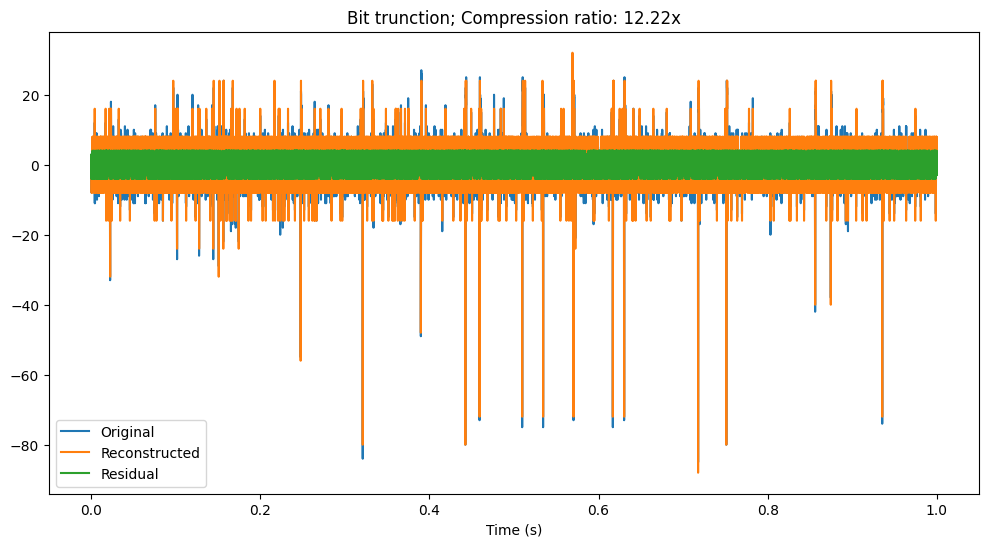

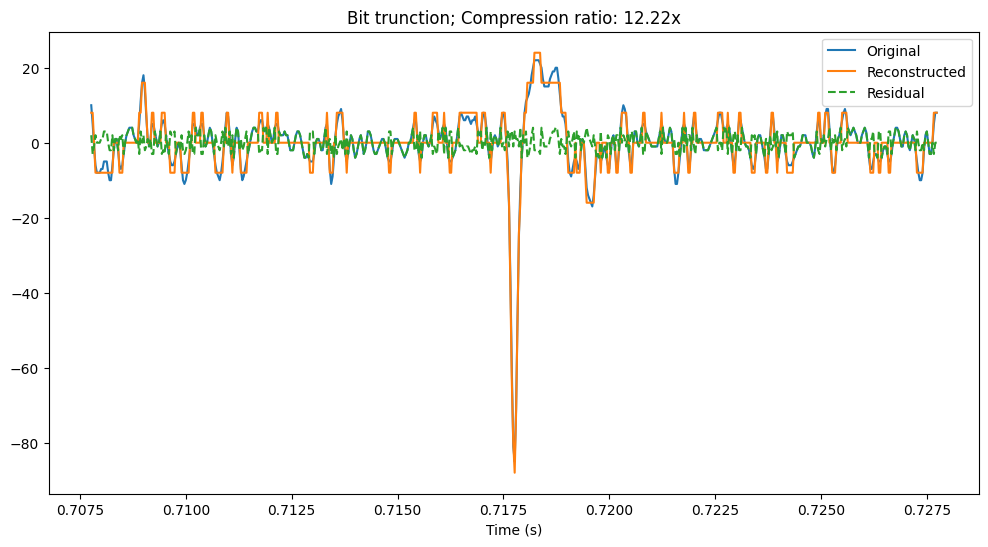

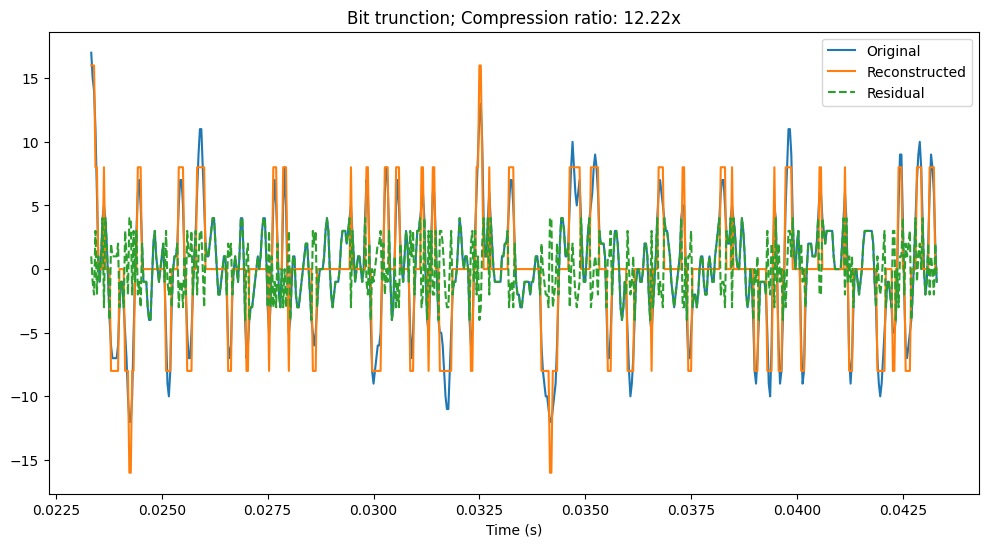

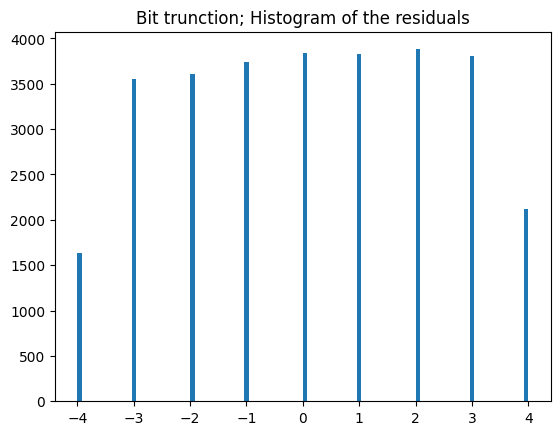

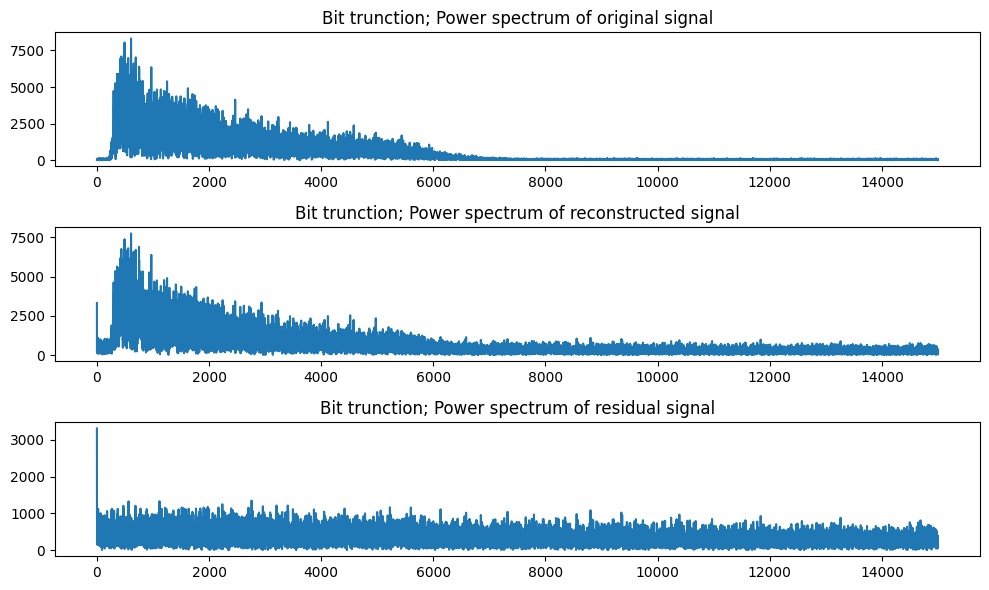

In [11]:
channel = 190

import matplotlib.pyplot as plt
plt.figure(figsize=(1200/100, 600/100), dpi=100)
plt.plot(grid, x[:, channel], label="Original")
plt.plot(grid, x_recon[:, channel], label="Reconstructed")
plt.plot(grid, resid[:, channel], label="Residual")
plt.title(f'Bit trunction; Compression ratio: {compression_ratio:.2f}x')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

# zoom in on a single spike
ind = np.argmin(x[:, channel])
rng = [ind - 300, ind + 300]
plt.figure(figsize=(1200/100, 600/100), dpi=100)
plt.plot(grid[rng[0]:rng[1]], x[rng[0]:rng[1], channel], label="Original")
plt.plot(grid[rng[0]:rng[1]], x_recon[rng[0]:rng[1], channel], label="Reconstructed")
plt.plot(grid[rng[0]:rng[1]], resid[rng[0]:rng[1], channel], '--', label="Residual")
plt.title(f'Bit trunction; Compression ratio: {compression_ratio:.2f}x')
plt.xlabel('Time (s)')
plt.legend()
plt.show()

# zoom in on a lower amplitude spike
ind = 1000
rng = [ind - 300, ind + 300]
plt.figure(figsize=(1200/100, 600/100), dpi=100)
plt.plot(grid[rng[0]:rng[1]], x[rng[0]:rng[1], channel], label="Original")
plt.plot(grid[rng[0]:rng[1]], x_recon[rng[0]:rng[1], channel], label="Reconstructed")
plt.plot(grid[rng[0]:rng[1]], resid[rng[0]:rng[1], channel], '--', label="Residual")
plt.title(f'Bit trunction; Compression ratio: {compression_ratio:.2f}x')
plt.xlabel('Time (s)')
plt.legend()

# Show the histogram of the residuals

plt.figure()
plt.hist(resid[:, channel], bins=100)
plt.title("Bit trunction; Histogram of the residuals")
plt.show()

fig, axs = plt.subplots(3, 1, figsize=(1000/100, 600/100), dpi=100)

# Power spectrum of original signal
axs[0].plot(np.abs(np.fft.rfft(x[:, channel])))
axs[0].set_title('Bit trunction; Power spectrum of original signal')

# Power spectrum of reconstructed signal
axs[1].plot(np.abs(np.fft.rfft(x_recon[:, channel])))
axs[1].set_title('Bit trunction; Power spectrum of reconstructed signal')

# Power spectrum of residual signal
axs[2].plot(np.abs(np.fft.rfft(resid[:, channel])))
axs[2].set_title('Bit trunction; Power spectrum of residual signal')

# Display the plot
plt.tight_layout()
plt.show()